# TetheredAI MLB Moneyline — Enhanced Feature EDA, SVM/XGBoost/LightGBM Modeling, and Champion Export

This notebook is the model lab for the MLB moneyline model. It assumes the GitHub Action has already created/committed:

- `data/odds.db`
- `data/processed/mlb_game_features.parquet`
- optionally `data/predictions/mlb_moneyline_predictions.csv`

The goals are:

1. audit the enhanced feature set,
2. compare baseline vs enhanced baseball feature groups,
3. tune multiple model families, including SVM, XGBoost, and LightGBM when installed,
4. evaluate probability quality with log loss, Brier score, AUC, and calibration,
5. manually export a champion model to `models/mlb_moneyline_champion.joblib`.

**Important:** betting model selection should prioritize calibrated probabilities and value detection, not classification accuracy alone.

## Research-informed feature priorities

The current enhanced feature pipeline is organized around features repeatedly used in baseball forecasting/betting projects and academic work:

- team form and run differential,
- starter quality and rest,
- bullpen workload/fatigue,
- offense vs opposing starter handedness,
- team offensive form from boxscore stats,
- Elo-style team strength,
- market odds as a separate scoring/backtesting layer, not part of the pure baseball model until historical odds coverage exists.

Keep two separate model concepts:

1. **Pure baseball model** — no market odds as inputs.
2. **Market-informed model** — uses odds/line movement once you have enough historical snapshots.

For now, this notebook defaults to pure baseball features.

In [1]:
from pathlib import Path
import json
import math
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
# Optional model libraries. The notebook will skip them if not installed.
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as exc:
    XGBClassifier = None
    HAS_XGBOOST = False
    print('XGBoost not available:', exc)

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception as exc:
    LGBMClassifier = None
    HAS_LIGHTGBM = False
    print('LightGBM not available:', exc)

print('HAS_XGBOOST:', HAS_XGBOOST)
print('HAS_LIGHTGBM:', HAS_LIGHTGBM)


HAS_XGBOOST: True
HAS_LIGHTGBM: True


In [3]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for p in candidates:
        if (p / 'data').exists() and (p / 'models').exists():
            return p
        if p.name == 'notebooks' and (p.parent / 'data').exists():
            return p.parent
    return cwd

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'models'
FEATURE_PATH = DATA_DIR / 'processed' / 'mlb_game_features.parquet'
PRED_PATH = DATA_DIR / 'predictions' / 'mlb_moneyline_predictions.csv'
DB_PATH = DATA_DIR / 'odds.db'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('FEATURE_PATH:', FEATURE_PATH, FEATURE_PATH.exists())
print('DB_PATH:', DB_PATH, DB_PATH.exists())
print('PRED_PATH:', PRED_PATH, PRED_PATH.exists())


PROJECT_ROOT: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app
FEATURE_PATH: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet True
DB_PATH: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\odds.db True
PRED_PATH: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\predictions\mlb_moneyline_predictions.csv True


In [4]:
features = pd.read_parquet(FEATURE_PATH)
features['game_datetime_utc'] = pd.to_datetime(features['game_datetime_utc'], utc=True, errors='coerce')
features['official_date'] = pd.to_datetime(features['official_date'], errors='coerce')

completed = features[features['target_home_win'].notna()].copy()
completed = completed.sort_values(['game_datetime_utc', 'game_pk']).reset_index(drop=True)
completed['target_home_win'] = completed['target_home_win'].astype(int)

print('All feature rows:', len(features))
print('Completed rows:', len(completed))
print('Date range:', completed['official_date'].min(), 'to', completed['official_date'].max())
print('Home win rate:', completed['target_home_win'].mean())
display(completed.head())


All feature rows: 5619
Completed rows: 5402
Date range: 2024-05-29 00:00:00 to 2026-05-28 00:00:00
Home win rate: 0.5327656423546835


,game_pk,season,game_type,official_date,game_datetime_utc,venue_id,venue_name,home_team_id,home_team_name,home_team_norm,away_team_id,away_team_name,away_team_norm,home_score,away_score,target_home_win,home_margin,total_runs,probable_home_pitcher_id,probable_home_pitcher_name,probable_away_pitcher_id,probable_away_pitcher_name,status_code,detailed_state,abstract_state,home_games_played_to_date,home_rest_days,home_win_season_to_date,home_win_last3,home_win_last5,home_win_last10,home_win_last20,home_runs_for_season_to_date,home_runs_for_last3,home_runs_for_last5,home_runs_for_last10,home_runs_for_last20,home_runs_against_season_to_date,home_runs_against_last3,home_runs_against_last5,home_runs_against_last10,home_runs_against_last20,home_run_diff_season_to_date,home_run_diff_last3,home_run_diff_last5,home_run_diff_last10,home_run_diff_last20,away_games_played_to_date,away_rest_days,away_win_season_to_date,away_win_last3,away_win_last5,away_win_last10,away_win_last20,away_runs_for_season_to_date,away_runs_for_last3,away_runs_for_last5,away_runs_for_last10,away_runs_for_last20,away_runs_against_season_to_date,away_runs_against_last3,away_runs_against_last5,away_runs_against_last10,away_runs_against_last20,away_run_diff_season_to_date,away_run_diff_last3,away_run_diff_last5,away_run_diff_last10,away_run_diff_last20,diff_win_season_to_date,diff_win_last3,diff_win_last5,diff_win_last10,diff_win_last20,diff_runs_for_season_to_date,diff_runs_for_last3,diff_runs_for_last5,diff_runs_for_last10,diff_runs_for_last20,diff_runs_against_season_to_date,diff_runs_against_last3,diff_runs_against_last5,diff_runs_against_last10,diff_runs_against_last20,diff_run_diff_season_to_date,diff_run_diff_last3,diff_run_diff_last5,diff_run_diff_last10,diff_run_diff_last20,diff_rest_days,diff_games_played_to_date,home_starter_pitcher_name,home_starter_pitcher_hand,home_starter_games_to_date,home_starter_days_since_last_start,home_starter_era_season_to_date,home_starter_whip_season_to_date,home_starter_k_per_9_season_to_date,home_starter_bb_per_9_season_to_date,home_starter_hr_per_9_season_to_date,...,diff_starter_era_last10,diff_starter_whip_last10,diff_starter_k_per_9_last10,diff_starter_bb_per_9_last10,diff_starter_hr_per_9_last10,diff_starter_k_minus_bb_per_bf_last10,diff_starter_ip_per_start_last10,diff_starter_pitches_per_start_last10,home_team_vs_hand_games_to_date,home_team_vs_hand_runs_season_to_date,home_team_vs_hand_runs_last10,home_team_vs_hand_runs_last20,home_team_vs_hand_home_runs_season_to_date,home_team_vs_hand_home_runs_last10,home_team_vs_hand_home_runs_last20,home_team_vs_hand_bb_per_ab_season_to_date,home_team_vs_hand_bb_per_ab_last10,home_team_vs_hand_bb_per_ab_last20,home_team_vs_hand_k_per_ab_season_to_date,home_team_vs_hand_k_per_ab_last10,home_team_vs_hand_k_per_ab_last20,home_team_vs_hand_ops_season_to_date,home_team_vs_hand_ops_last10,home_team_vs_hand_ops_last20,home_team_vs_hand_obp_season_to_date,home_team_vs_hand_obp_last10,home_team_vs_hand_obp_last20,home_team_vs_hand_slg_season_to_date,home_team_vs_hand_slg_last10,home_team_vs_hand_slg_last20,home_opp_starter_is_lhp,home_opp_starter_is_rhp,away_team_vs_hand_games_to_date,away_team_vs_hand_runs_season_to_date,away_team_vs_hand_runs_last10,away_team_vs_hand_runs_last20,away_team_vs_hand_home_runs_season_to_date,away_team_vs_hand_home_runs_last10,away_team_vs_hand_home_runs_last20,away_team_vs_hand_bb_per_ab_season_to_date,away_team_vs_hand_bb_per_ab_last10,away_team_vs_hand_bb_per_ab_last20,away_team_vs_hand_k_per_ab_season_to_date,away_team_vs_hand_k_per_ab_last10,away_team_vs_hand_k_per_ab_last20,away_team_vs_hand_ops_season_to_date,away_team_vs_hand_ops_last10,away_team_vs_hand_ops_last20,away_team_vs_hand_obp_season_to_date,away_team_vs_hand_obp_last10,away_team_vs_hand_obp_last20,away_team_vs_hand_slg_season_to_date,away_team_vs_hand_slg_last10,away_team_vs_hand_slg_last20,away_opp_starter_is_lhp,away_opp_starter_is_rhp,diff_team_vs_hand_games_to_date,diff_team_vs_hand_runs

## Feature-engineering audit checks

These checks verify that the enhanced feature file contains the expected feature families and that the default pure-baseball feature list excludes obvious postgame leakage fields and raw numeric IDs such as `venue_id`.

In [5]:
REQUIRED_FEATURE_GROUPS = {
    'elo': ['home_elo_pre', 'away_elo_pre', 'diff_elo_pre', 'elo_home_win_prob'],
    'starter': ['home_starter_', 'away_starter_', 'diff_starter_'],
    'bullpen': ['home_bullpen_', 'away_bullpen_', 'diff_bullpen_'],
    'team_boxscore': ['home_team_box_', 'away_team_box_', 'diff_team_box_'],
    'team_vs_hand': ['home_team_vs_hand_', 'away_team_vs_hand_', 'diff_team_vs_hand_'],
}

LEAKAGE_CHECK_COLS = {
    'home_score', 'away_score', 'target_home_win', 'home_margin', 'total_runs',
    'status_code', 'detailed_state', 'abstract_state',
}

def count_group_columns(frame, items):
    found = []
    for item in items:
        if item.endswith('_'):
            found.extend([c for c in frame.columns if c.startswith(item)])
        elif item in frame.columns:
            found.append(item)
    return sorted(set(found))

feature_group_audit = []
for group, items in REQUIRED_FEATURE_GROUPS.items():
    found = count_group_columns(features, items)
    non_null_top = (
        features[found].notna().mean().sort_values(ascending=False).head(5).to_dict()
        if found else {}
    )
    feature_group_audit.append({
        'group': group,
        'columns_found': len(found),
        'top_non_null_rates': non_null_top,
    })

display(pd.DataFrame(feature_group_audit))


,group,columns_found,top_non_null_rates
0,elo,0,{}
1,starter,106,{'away_starter_pitcher_hand': 0.96974550631785...
2,bullpen,0,{}
3,team_boxscore,0,{}
4,team_vs_hand,66,{'away_team_vs_hand_bb_per_ab_last10': 0.96565...


In [6]:
def summarize_missingness(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isna().sum().values,
        'missing_pct': df.isna().mean().values,
        'non_null_pct': df.notna().mean().values,
    })
    return out.sort_values(['missing_pct', 'column'], ascending=[False, True]).reset_index(drop=True)

missing_all = summarize_missingness(completed)
display(missing_all.head(40))


,column,missing_count,missing_pct,non_null_pct
0,away_moneyline_median,5402,1.000000,0.000000
1,away_spread_median,5402,1.000000,0.000000
2,away_spread_price_median,5402,1.000000,0.000000
3,book_count_h2h_away,5402,1.000000,0.000000
4,book_count_h2h_home,5402,1.000000,0.000000
5,event_date,5402,1.000000,0.000000
6,event_id,5402,1.000000,0.000000
7,home_moneyline_median,5402,1.000000,0.000000
8,home_spread_median,5402,1.000000,0.000000
9,home_spread_price_median,5402,1.000000,0.000000


In [7]:
POSTGAME_BLOCK = {
    'home_score', 'away_score', 'target_home_win', 'home_margin', 'total_runs',
    'detailed_state', 'abstract_state', 'status_code',
}
ID_BLOCK = {
    'game_pk', 'season', 'game_type', 'official_date', 'game_datetime_utc',
    'venue_name', 'home_team_name', 'home_team_norm', 'away_team_name', 'away_team_norm',
    'home_team_id', 'away_team_id', 'home_team', 'away_team',
    'probable_home_pitcher_name', 'probable_away_pitcher_name',
    'probable_home_pitcher_id', 'probable_away_pitcher_id',
    'event_id', 'event_date', 'odds_home_team', 'odds_away_team',
}
MARKET_KEYWORDS = [
    'market_', 'moneyline', 'spread', 'total_points', 'over_price', 'under_price',
    'book_count', 'vig', 'odds_', 'event_id', 'event_date'
]

def is_market_feature(col: str) -> bool:
    c = col.lower()
    return any(k in c for k in MARKET_KEYWORDS)

def candidate_feature_columns(frame: pd.DataFrame, include_market: bool = False, min_non_null_rate: float = 0.05) -> list[str]:
    numeric_cols = frame.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    out = []
    for c in numeric_cols:
        if c in POSTGAME_BLOCK or c in ID_BLOCK or c.endswith('_score'):
            continue
        if not include_market and is_market_feature(c):
            continue
        if min_non_null_rate is not None and frame[c].notna().mean() < min_non_null_rate:
            continue
        out.append(c)
    return out

all_pure_features = candidate_feature_columns(completed, include_market=False, min_non_null_rate=0.05)
market_features = [c for c in completed.select_dtypes(include=[np.number, 'bool']).columns if is_market_feature(c)]

print('Pure candidate features:', len(all_pure_features))
print('Market features excluded:', len(market_features))
display(pd.DataFrame({'pure_features': all_pure_features}).head(100))


leaks = sorted(set(all_pure_features) & LEAKAGE_CHECK_COLS)
print('Leakage columns in pure features:', leaks)
print('venue_id in pure features:', 'venue_id' in all_pure_features)
assert not leaks, f'Leakage columns found in pure feature list: {leaks}'
assert 'venue_id' not in all_pure_features, 'venue_id should be excluded; use explicit park-factor features later.'


Pure candidate features: 241
Market features excluded: 16


,pure_features
0,venue_id
1,home_games_played_to_date
2,home_rest_days
3,home_win_season_to_date
4,home_win_last3
...,...
95,home_starter_k_per_9_last10
96,home_starter_bb_per_9_last10
97,home_starter_hr_per_9_last10
98,home_starter_k_minus_bb_per_bf_last10


Leakage columns in pure features: []
venue_id in pure features: True


AssertionError: venue_id should be excluded; use explicit park-factor features later.

In [8]:
feature_groups = {
    'baseline_team_form': [
        c for c in all_pure_features
        if (
            c.startswith('home_win_') or c.startswith('away_win_') or c.startswith('diff_win_')
            or c.startswith('home_runs_for_') or c.startswith('away_runs_for_') or c.startswith('diff_runs_for_')
            or c.startswith('home_runs_against_') or c.startswith('away_runs_against_') or c.startswith('diff_runs_against_')
            or c.startswith('home_run_diff_') or c.startswith('away_run_diff_') or c.startswith('diff_run_diff_')
            or c in ['home_rest_days', 'away_rest_days', 'diff_rest_days', 'game_month', 'game_dayofweek']
        )
    ],
    'elo_only': [c for c in all_pure_features if 'elo' in c],
    'starter': [c for c in all_pure_features if 'starter_' in c],
    'bullpen': [c for c in all_pure_features if 'bullpen_' in c],
    'team_boxscore': [c for c in all_pure_features if 'team_box_' in c],
    'team_vs_hand': [c for c in all_pure_features if 'team_vs_hand_' in c or 'opp_starter_is_' in c],
}

feature_sets = {
    'baseline_team_form': sorted(set(feature_groups['baseline_team_form'])),
    'baseline_plus_elo': sorted(set(feature_groups['baseline_team_form'] + feature_groups['elo_only'])),
    'starter_only': sorted(set(feature_groups['starter'] + feature_groups['elo_only'] + ['game_month', 'game_dayofweek'])),
    'baseline_starter_bullpen': sorted(set(feature_groups['baseline_team_form'] + feature_groups['elo_only'] + feature_groups['starter'] + feature_groups['bullpen'])),
    'enhanced_all_pure': sorted(set(all_pure_features)),
}

summary = []
for name, cols in feature_sets.items():
    summary.append({
        'feature_set': name,
        'features': len(cols),
        'avg_missing_pct': completed[cols].isna().mean().mean() if cols else np.nan,
        'max_missing_pct': completed[cols].isna().mean().max() if cols else np.nan,
    })
display(pd.DataFrame(summary).sort_values('features'))


,feature_set,features,avg_missing_pct,max_missing_pct
0,baseline_team_form,65,0.003828,0.004443
1,baseline_plus_elo,65,0.003828,0.004443
2,starter_only,108,0.063882,0.091633
3,baseline_starter_bullpen,171,0.041802,0.091633
4,enhanced_all_pure,241,0.031806,0.091633


In [9]:
# Feature missingness by group
for group, cols in feature_groups.items():
    print('\n' + '='*90)
    print(group, 'feature_count=', len(cols))
    if cols:
        display(summarize_missingness(completed[cols]).head(20))



baseline_team_form feature_count= 65


,column,missing_count,missing_pct,non_null_pct
0,diff_rest_days,24,0.004443,0.995557
1,diff_run_diff_last10,24,0.004443,0.995557
2,diff_run_diff_last20,24,0.004443,0.995557
3,diff_run_diff_last3,24,0.004443,0.995557
4,diff_run_diff_last5,24,0.004443,0.995557
5,diff_run_diff_season_to_date,24,0.004443,0.995557
6,diff_runs_against_last10,24,0.004443,0.995557
7,diff_runs_against_last20,24,0.004443,0.995557
8,diff_runs_against_last3,24,0.004443,0.995557
9,diff_runs_against_last5,24,0.004443,0.995557



elo_only feature_count= 0

starter feature_count= 106


,column,missing_count,missing_pct,non_null_pct
0,diff_starter_bb_per_9_last10,495,0.091633,0.908367
1,diff_starter_bb_per_9_last3,495,0.091633,0.908367
2,diff_starter_bb_per_9_last5,495,0.091633,0.908367
3,diff_starter_bb_per_9_season_to_date,495,0.091633,0.908367
4,diff_starter_era_last10,495,0.091633,0.908367
5,diff_starter_era_last3,495,0.091633,0.908367
6,diff_starter_era_last5,495,0.091633,0.908367
7,diff_starter_era_season_to_date,495,0.091633,0.908367
8,diff_starter_hr_per_9_last10,495,0.091633,0.908367
9,diff_starter_hr_per_9_last3,495,0.091633,0.908367



bullpen feature_count= 0

team_boxscore feature_count= 0

team_vs_hand feature_count= 70


,column,missing_count,missing_pct,non_null_pct
0,diff_team_vs_hand_bb_per_ab_last10,54,0.009996,0.990004
1,diff_team_vs_hand_bb_per_ab_last20,54,0.009996,0.990004
2,diff_team_vs_hand_bb_per_ab_season_to_date,54,0.009996,0.990004
3,diff_team_vs_hand_games_to_date,54,0.009996,0.990004
4,diff_team_vs_hand_home_runs_last10,54,0.009996,0.990004
5,diff_team_vs_hand_home_runs_last20,54,0.009996,0.990004
6,diff_team_vs_hand_home_runs_season_to_date,54,0.009996,0.990004
7,diff_team_vs_hand_k_per_ab_last10,54,0.009996,0.990004
8,diff_team_vs_hand_k_per_ab_last20,54,0.009996,0.990004
9,diff_team_vs_hand_k_per_ab_season_to_date,54,0.009996,0.990004


In [10]:
# Time-based holdout. Do not use random splitting for production-style sports modeling.
HOLDOUT_DAYS = 60
max_date = completed['game_datetime_utc'].max()
cutoff = max_date - pd.Timedelta(days=HOLDOUT_DAYS)
train_df = completed[completed['game_datetime_utc'] < cutoff].copy()
holdout_df = completed[completed['game_datetime_utc'] >= cutoff].copy()

print('Cutoff:', cutoff)
print('Train:', train_df['official_date'].min(), train_df['official_date'].max(), len(train_df))
print('Holdout:', holdout_df['official_date'].min(), holdout_df['official_date'].max(), len(holdout_df))
print('Train home win rate:', train_df['target_home_win'].mean())
print('Holdout home win rate:', holdout_df['target_home_win'].mean())


Cutoff: 2026-03-30 00:05:00+00:00
Train: 2024-05-29 00:00:00 2026-03-29 00:00:00 4604
Holdout: 2026-03-30 00:00:00 2026-05-28 00:00:00 798
Train home win rate: 0.5351867940920938
Holdout home win rate: 0.518796992481203


In [11]:
def evaluate_probs(y_true, proba, threshold=0.5):
    proba = np.asarray(proba, dtype=float)
    pred = (proba >= threshold).astype(int)
    out = {
        'accuracy': accuracy_score(y_true, pred),
        'log_loss': log_loss(y_true, np.clip(proba, 1e-6, 1 - 1e-6)),
        'brier': brier_score_loss(y_true, proba),
        'auc': roc_auc_score(y_true, proba) if len(np.unique(y_true)) > 1 else np.nan,
        'avg_pred': float(np.mean(proba)),
        'actual_rate': float(np.mean(y_true)),
    }
    return out

def calibration_table(y_true, proba, bins=None):
    if bins is None:
        bins = [0, .35, .40, .45, .50, .55, .60, .65, .70, 1]
    tmp = pd.DataFrame({'y': y_true, 'p': proba})
    tmp['prob_bucket'] = pd.cut(tmp['p'], bins=bins, include_lowest=True)
    return tmp.groupby('prob_bucket').agg(
        games=('y', 'size'),
        avg_pred_prob=('p', 'mean'),
        actual_home_win_rate=('y', 'mean'),
    ).assign(calibration_error=lambda x: x['actual_home_win_rate'] - x['avg_pred_prob'])

# Baseline: use train home win rate as constant probability.
y_train = train_df['target_home_win'].astype(int)
y_holdout = holdout_df['target_home_win'].astype(int)
base_prob = np.repeat(y_train.mean(), len(y_holdout))
print('Constant home-rate baseline')
print(evaluate_probs(y_holdout, base_prob))


Constant home-rate baseline
{'accuracy': 0.518796992481203, 'log_loss': 0.6929795494349857, 'brier': 0.249915298670506, 'auc': 0.5, 'avg_pred': 0.5351867940920938, 'actual_rate': 0.518796992481203}


## Model candidates, including SVM

The SVM candidate uses an RBF kernel and `probability=True` so it produces probabilities for log loss, Brier score, calibration, and betting comparisons. It is scaled with `StandardScaler` and intentionally uses a modest grid because SVM probability calibration can be slower than tree models.

In [12]:
def make_model_candidates(random_state=42):
    candidates = {}
    candidates['logistic'] = {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=5000, solver='lbfgs')),
        ]),
        'params': {
            'model__C': [0.01, 0.05, 0.1, 0.25, 0.5, 1.0],
            'model__class_weight': [None, 'balanced'],
        }
    }
    candidates['svm_rbf'] = {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('scaler', StandardScaler()),
            ('model', SVC(
                kernel='rbf',
                probability=True,
                cache_size=1500,
                random_state=random_state,
            )),
        ]),
        # Keep this grid intentionally modest. SVMs can be slow because
        # probability=True fits an internal calibration model.
        'params': {
            'model__C': [0.25, 0.5, 1.0, 2.0],
            'model__gamma': ['scale', 0.01, 0.03, 0.10],
            'model__class_weight': [None, 'balanced'],
        }
    }
    candidates['random_forest'] = {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('model', RandomForestClassifier(random_state=random_state, n_jobs=-1)),
        ]),
        'params': {
            'model__n_estimators': [300, 500],
            'model__max_depth': [3, 4, 5, 7, None],
            'model__min_samples_leaf': [25, 50, 75, 100],
            'model__max_features': ['sqrt', 0.4, 0.6],
        }
    }
    candidates['extra_trees'] = {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('model', ExtraTreesClassifier(random_state=random_state, n_jobs=-1)),
        ]),
        'params': {
            'model__n_estimators': [300, 500],
            'model__max_depth': [3, 4, 5, 7, None],
            'model__min_samples_leaf': [25, 50, 75, 100],
            'model__max_features': ['sqrt', 0.4, 0.6],
        }
    }
    candidates['hist_gradient_boosting'] = {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  # HGB also handles NaN, but median keeps parity.
            ('model', HistGradientBoostingClassifier(random_state=random_state, early_stopping=True)),
        ]),
        'params': {
            'model__learning_rate': [0.02, 0.04, 0.06, 0.10],
            'model__max_iter': [150, 250, 400],
            'model__max_leaf_nodes': [7, 15, 31],
            'model__l2_regularization': [0.0, 0.1, 1.0],
            'model__min_samples_leaf': [20, 50, 100],
        }
    }
    if HAS_XGBOOST:
        candidates['xgboost'] = {
            'estimator': Pipeline([
                ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
                ('model', XGBClassifier(
                    objective='binary:logistic',
                    eval_metric='logloss',
                    random_state=random_state,
                    n_jobs=-1,
                    tree_method='hist',
                )),
            ]),
            'params': {
                'model__n_estimators': [150, 250, 400, 600],
                'model__max_depth': [2, 3, 4],
                'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
                'model__subsample': [0.7, 0.85, 1.0],
                'model__colsample_bytree': [0.7, 0.85, 1.0],
                'model__min_child_weight': [5, 10, 20],
                'model__reg_alpha': [0.0, 0.1, 0.5],
                'model__reg_lambda': [1.0, 3.0, 10.0],
            }
        }
    if HAS_LIGHTGBM:
        candidates['lightgbm'] = {
            'estimator': Pipeline([
                ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
                ('model', LGBMClassifier(
                    objective='binary',
                    random_state=random_state,
                    n_jobs=-1,
                    verbose=-1,
                )),
            ]),
            'params': {
                'model__n_estimators': [150, 250, 400, 600],
                'model__num_leaves': [7, 15, 31],
                'model__max_depth': [2, 3, 4, -1],
                'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
                'model__subsample': [0.7, 0.85, 1.0],
                'model__colsample_bytree': [0.7, 0.85, 1.0],
                'model__min_child_samples': [20, 50, 100],
                'model__reg_alpha': [0.0, 0.1, 0.5],
                'model__reg_lambda': [1.0, 3.0, 10.0],
            }
        }
    return candidates

candidates = make_model_candidates()
print('Candidates:', list(candidates))


Candidates: ['logistic', 'svm_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'lightgbm']


In [13]:
def grid_size(params):
    n = 1
    for values in params.values():
        n *= len(values)
    return n

def tune_one_model(X_train, y_train, X_holdout, y_holdout, candidate_name, candidate, cv_splits=4, max_iter_search=40, random_state=42):
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    n_grid = grid_size(candidate['params'])
    if n_grid <= max_iter_search:
        search = GridSearchCV(
            estimator=candidate['estimator'],
            param_grid=candidate['params'],
            scoring='neg_log_loss',
            cv=tscv,
            n_jobs=-1,
            refit=True,
        )
        search_type = 'grid'
    else:
        search = RandomizedSearchCV(
            estimator=candidate['estimator'],
            param_distributions=candidate['params'],
            n_iter=max_iter_search,
            scoring='neg_log_loss',
            cv=tscv,
            n_jobs=-1,
            random_state=random_state,
            refit=True,
        )
        search_type = 'randomized'
    search.fit(X_train, y_train)
    best = search.best_estimator_
    prob = best.predict_proba(X_holdout)[:, 1]
    metrics = evaluate_probs(y_holdout, prob)
    return {
        'model_name': candidate_name,
        'search_type': search_type,
        'best_estimator': best,
        'best_params': search.best_params_,
        'cv_best_neg_log_loss': float(search.best_score_),
        'holdout_prob': prob,
        **metrics,
    }


In [14]:
# Main model comparison. Adjust these to control runtime.
RUN_FULL_SEARCH = True
MAX_ITER_SEARCH = 30
RUN_SVM = True  # Set False if runtime is too slow.
MODEL_FAMILIES_TO_RUN = ['logistic', 'random_forest', 'extra_trees', 'hist_gradient_boosting']
if RUN_SVM:
    MODEL_FAMILIES_TO_RUN.append('svm_rbf')
if HAS_XGBOOST:
    MODEL_FAMILIES_TO_RUN.append('xgboost')
if HAS_LIGHTGBM:
    MODEL_FAMILIES_TO_RUN.append('lightgbm')

results = []
models = {}
for feature_set_name, cols in feature_sets.items():
    if not cols:
        continue
    X_train = train_df[cols]
    X_holdout = holdout_df[cols]
    for model_name in MODEL_FAMILIES_TO_RUN:
        print(f'Fitting {feature_set_name}__{model_name} with {len(cols)} features...')
        res = tune_one_model(
            X_train, y_train, X_holdout, y_holdout,
            candidate_name=model_name,
            candidate=candidates[model_name],
            max_iter_search=MAX_ITER_SEARCH,
        )
        key = f'{feature_set_name}__{model_name}'
        res['key'] = key
        res['feature_set'] = feature_set_name
        res['feature_count'] = len(cols)
        res['feature_cols'] = cols
        results.append({k: v for k, v in res.items() if k not in {'best_estimator', 'holdout_prob', 'feature_cols'}})
        models[key] = res

results_df = pd.DataFrame(results).sort_values(['log_loss', 'brier', 'auc'], ascending=[True, True, False])
display(results_df)


Fitting baseline_team_form__logistic with 65 features...
Fitting baseline_team_form__random_forest with 65 features...
Fitting baseline_team_form__extra_trees with 65 features...
Fitting baseline_team_form__hist_gradient_boosting with 65 features...
Fitting baseline_team_form__svm_rbf with 65 features...
Fitting baseline_team_form__xgboost with 65 features...
Fitting baseline_team_form__lightgbm with 65 features...
Fitting baseline_plus_elo__logistic with 65 features...
Fitting baseline_plus_elo__random_forest with 65 features...
Fitting baseline_plus_elo__extra_trees with 65 features...
Fitting baseline_plus_elo__hist_gradient_boosting with 65 features...
Fitting baseline_plus_elo__svm_rbf with 65 features...
Fitting baseline_plus_elo__xgboost with 65 features...
Fitting baseline_plus_elo__lightgbm with 65 features...
Fitting starter_only__logistic with 108 features...
Fitting starter_only__random_forest with 108 features...
Fitting starter_only__extra_trees with 108 features...
Fitti

,model_name,search_type,best_params,cv_best_neg_log_loss,accuracy,log_loss,brier,auc,avg_pred,actual_rate,key,feature_set,feature_count
34,lightgbm,randomized,"{'model__subsample': 0.85, 'model__reg_lambda'...",-0.686268,0.535088,0.687294,0.247100,0.557845,0.535729,0.518797,enhanced_all_pure__lightgbm,enhanced_all_pure,241
29,random_forest,randomized,"{'model__n_estimators': 500, 'model__min_sampl...",-0.683916,0.535088,0.687640,0.247267,0.555933,0.535075,0.518797,enhanced_all_pure__random_forest,enhanced_all_pure,241
26,xgboost,randomized,"{'model__subsample': 0.7, 'model__reg_lambda':...",-0.685596,0.530075,0.687672,0.247284,0.559405,0.536863,0.518797,baseline_starter_bullpen__xgboost,baseline_starter_bullpen,171
27,lightgbm,randomized,"{'model__subsample': 1.0, 'model__reg_lambda':...",-0.684429,0.517544,0.687873,0.247395,0.557499,0.537434,0.518797,baseline_starter_bullpen__lightgbm,baseline_starter_bullpen,171
6,lightgbm,randomized,"{'model__subsample': 0.85, 'model__reg_lambda'...",-0.686012,0.547619,0.687875,0.247386,0.556738,0.537692,0.518797,baseline_team_form__lightgbm,baseline_team_form,65
13,lightgbm,randomized,"{'model__subsample': 0.85, 'model__reg_lambda'...",-0.686012,0.547619,0.687875,0.247386,0.556738,0.537692,0.518797,baseline_plus_elo__lightgbm,baseline_plus_elo,65
22,random_forest,randomized,"{'model__n_estimators': 300, 'model__min_sampl...",-0.684224,0.528822,0.687932,0.247425,0.554191,0.535048,0.518797,baseline_starter_bullpen__random_forest,baseline_starter_bullpen,171
33,xgboost,randomized,"{'model__subsample': 0.7, 'model__reg_lambda':...",-0.685178,0.538847,0.688022,0.247459,0.558109,0.535851,0.518797,enhanced_all_pure__xgboost,enhanced_all_pure,241
5,xgboost,randomized,"{'model__subsample': 0.7, 'model__reg_lambda':...",-0.686209,0.543860,0.688185,0.247528,0.555367,0.539797,0.518797,baseline_team_form__xgboost,baseline_team_form,65
12,xgboost,randomized,"{'model__subsample': 0.7, 'model__reg_lambda':...",-0.686209,0.543860,0.688185,0.247528,0.555367,0.539797,0.518797,baseline_plus_elo__xgboost,baseline_plus_elo,65


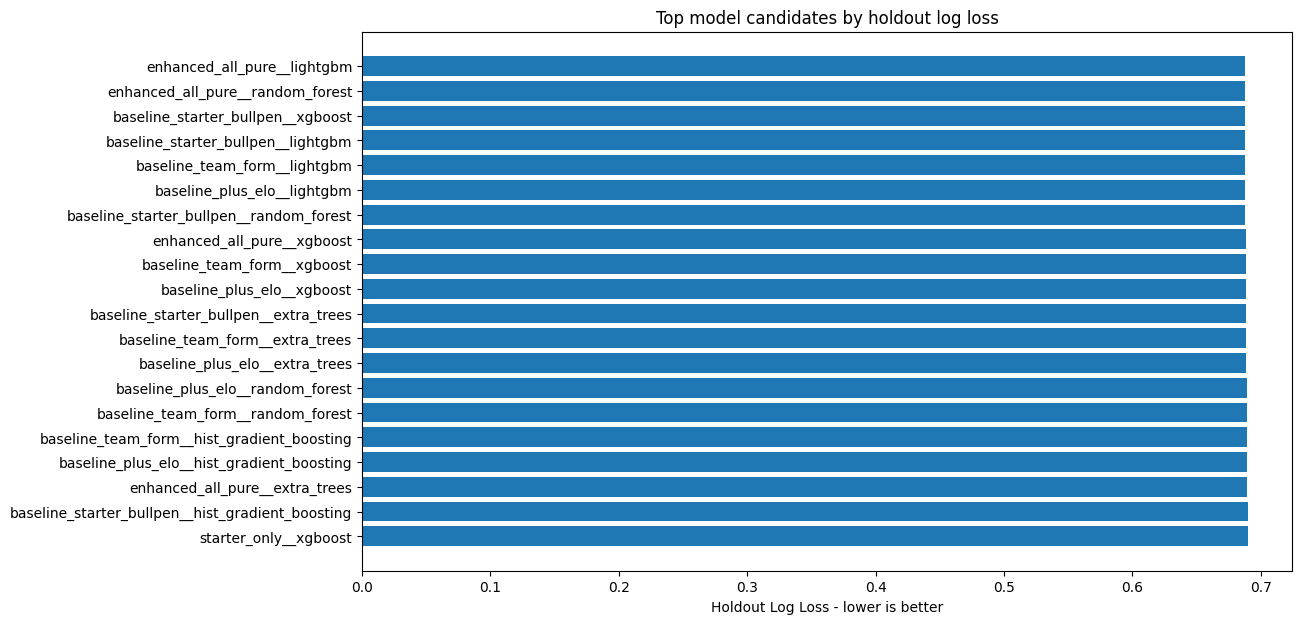

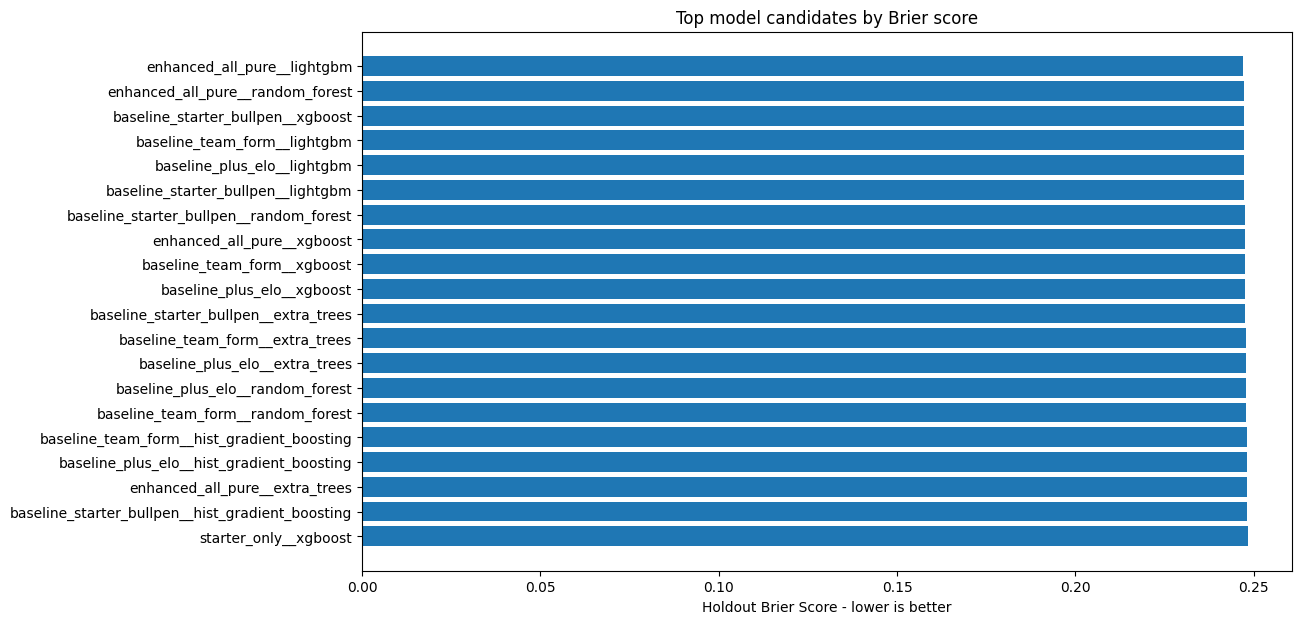

In [15]:
# Visual model comparison
if len(results_df):
    plot_df = results_df.head(20).copy().sort_values('log_loss', ascending=True)
    plt.figure(figsize=(12, max(5, len(plot_df) * 0.35)))
    plt.barh(plot_df['key'], plot_df['log_loss'])
    plt.xlabel('Holdout Log Loss - lower is better')
    plt.title('Top model candidates by holdout log loss')
    plt.gca().invert_yaxis()
    plt.show()

    plot_df = results_df.head(20).copy().sort_values('brier', ascending=True)
    plt.figure(figsize=(12, max(5, len(plot_df) * 0.35)))
    plt.barh(plot_df['key'], plot_df['brier'])
    plt.xlabel('Holdout Brier Score - lower is better')
    plt.title('Top model candidates by Brier score')
    plt.gca().invert_yaxis()
    plt.show()


In [16]:
best_key = results_df.iloc[0]['key']
best = models[best_key]
print('Best model:', best_key)
print('Feature count:', best['feature_count'])
print('Best params:', best['best_params'])
print('Metrics:', {k: best[k] for k in ['accuracy', 'log_loss', 'brier', 'auc', 'avg_pred', 'actual_rate']})

prob = best['holdout_prob']
pred = (prob >= 0.5).astype(int)
print('\nClassification report:')
print(classification_report(y_holdout, pred, digits=3))
print('\nConfusion matrix:')
display(pd.DataFrame(confusion_matrix(y_holdout, pred), index=['actual_away', 'actual_home'], columns=['pred_away', 'pred_home']))


Best model: enhanced_all_pure__lightgbm
Feature count: 241
Best params: {'model__subsample': 0.85, 'model__reg_lambda': 3.0, 'model__reg_alpha': 0.1, 'model__num_leaves': 15, 'model__n_estimators': 250, 'model__min_child_samples': 100, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
Metrics: {'accuracy': 0.5350877192982456, 'log_loss': 0.6872935618362577, 'brier': 0.24709993807797778, 'auc': 0.5578452093397746, 'avg_pred': 0.535729062241517, 'actual_rate': 0.518796992481203}

Classification report:
              precision    recall  f1-score   support

           0      0.534     0.263     0.353       384
           1      0.535     0.787     0.637       414

    accuracy                          0.535       798
   macro avg      0.535     0.525     0.495       798
weighted avg      0.535     0.535     0.500       798


Confusion matrix:


,pred_away,pred_home
actual_away,101,283
actual_home,88,326


,games,avg_pred_prob,actual_home_win_rate,calibration_error
prob_bucket,,,,
"(-0.001, 0.35]",0,NaN,NaN,NaN
"(0.35, 0.4]",0,NaN,NaN,NaN
"(0.4, 0.45]",32,0.436167,0.375000,-0.061167
"(0.45, 0.5]",157,0.477640,0.484076,0.006437
"(0.5, 0.55]",325,0.525244,0.489231,-0.036014
"(0.55, 0.6]",193,0.573095,0.569948,-0.003146
"(0.6, 0.65]",73,0.620823,0.616438,-0.004385
"(0.65, 0.7]",18,0.662960,0.666667,0.003706
"(0.7, 1.0]",0,NaN,NaN,NaN


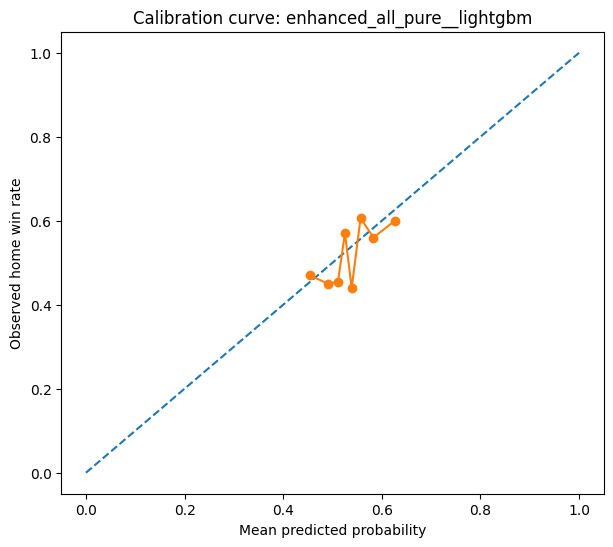

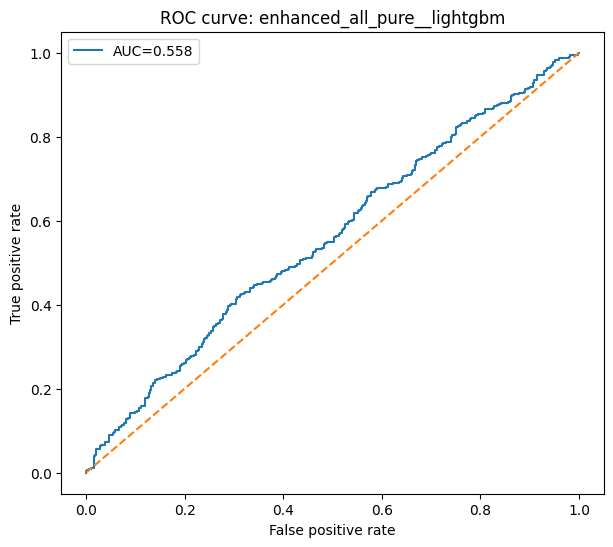

In [17]:
# Calibration analysis
prob = best['holdout_prob']
display(calibration_table(y_holdout, prob))

frac_pos, mean_pred = calibration_curve(y_holdout, prob, n_bins=8, strategy='quantile')
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(mean_pred, frac_pos, marker='o')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed home win rate')
plt.title(f'Calibration curve: {best_key}')
plt.show()

fpr, tpr, _ = roc_curve(y_holdout, prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC={best["auc"]:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title(f'ROC curve: {best_key}')
plt.legend()
plt.show()


In [18]:
# Optional calibration wrapper. Run this after choosing a strong base model.
CALIBRATION_METHODS = ['sigmoid', 'isotonic']
calibration_results = []
calibrated_models = {}

for method in CALIBRATION_METHODS:
    print('Calibrating with', method)
    cal = CalibratedClassifierCV(estimator=clone(best['best_estimator']), method=method, cv=TimeSeriesSplit(n_splits=4))
    cal.fit(train_df[best['feature_cols']], y_train)
    cal_prob = cal.predict_proba(holdout_df[best['feature_cols']])[:, 1]
    m = evaluate_probs(y_holdout, cal_prob)
    m['calibration_method'] = method
    calibration_results.append(m)
    calibrated_models[method] = {'estimator': cal, 'prob': cal_prob, 'metrics': m}

calibration_results_df = pd.DataFrame(calibration_results).sort_values(['log_loss', 'brier'])
display(calibration_results_df)


Calibrating with sigmoid
Calibrating with isotonic


,accuracy,log_loss,brier,auc,avg_pred,actual_rate,calibration_method
1,0.530075,0.689797,0.248288,0.551464,0.537152,0.518797,isotonic
0,0.545113,0.689875,0.248362,0.543617,0.538102,0.518797,sigmoid


,feature,importance_mean,importance_std
143,diff_team_vs_hand_obp_season_to_date,0.000947,0.000575
86,diff_run_diff_season_to_date,0.000935,0.000851
83,diff_run_diff_last20,0.000844,0.000690
36,away_starter_ip_per_start_season_to_date,0.000547,0.000402
225,home_team_vs_hand_obp_season_to_date,0.000499,0.000716
111,diff_starter_ip_per_start_last10,0.000459,0.000491
146,diff_team_vs_hand_ops_season_to_date,0.000371,0.000495
68,away_team_vs_hand_ops_season_to_date,0.000276,0.000124
133,diff_team_vs_hand_bb_per_ab_season_to_date,0.000254,0.000167
66,away_team_vs_hand_ops_last10,0.000211,0.000517


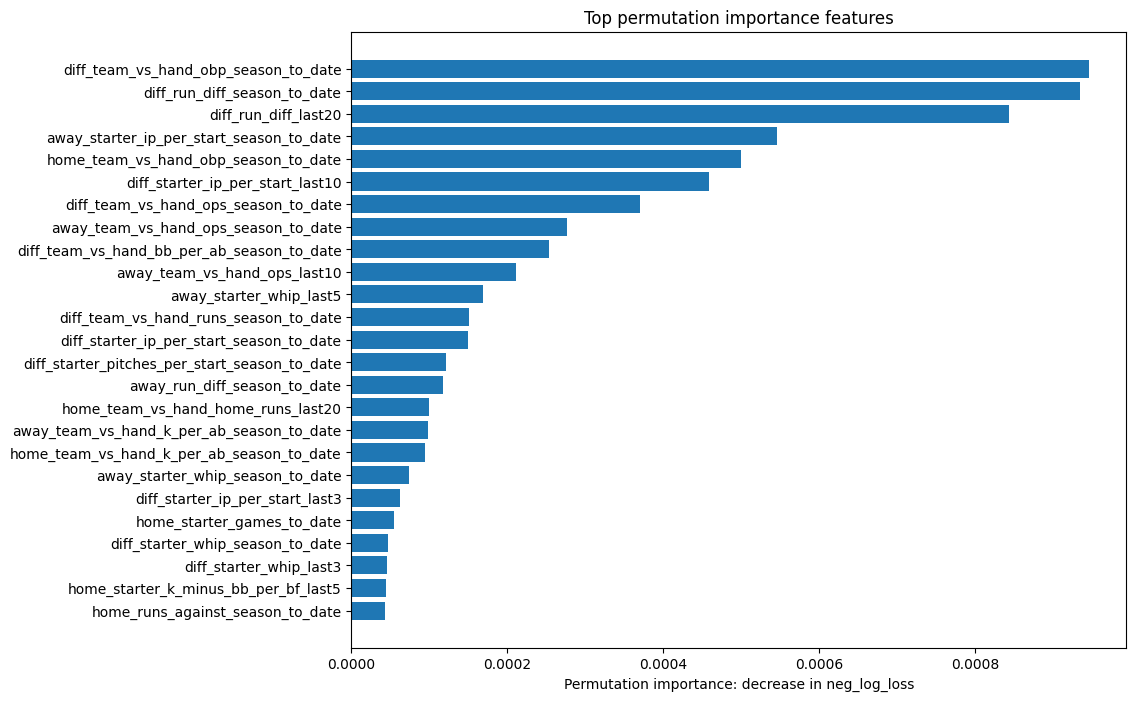

In [19]:
# Permutation importance for the selected model. This can take a minute.
RUN_PERMUTATION_IMPORTANCE = True
if RUN_PERMUTATION_IMPORTANCE:
    X_hold = holdout_df[best['feature_cols']]
    perm = permutation_importance(
        best['best_estimator'],
        X_hold,
        y_holdout,
        n_repeats=5,
        random_state=42,
        scoring='neg_log_loss',
        n_jobs=-1,
    )
    importance = pd.DataFrame({
        'feature': best['feature_cols'],
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(importance.head(40))

    top = importance.head(25).sort_values('importance_mean')
    plt.figure(figsize=(10, 8))
    plt.barh(top['feature'], top['importance_mean'])
    plt.xlabel('Permutation importance: decrease in neg_log_loss')
    plt.title('Top permutation importance features')
    plt.show()


In [20]:
# Market/betting diagnostics once historical odds coverage becomes available.
# This section is intentionally skipped when market columns are 100% missing.
market_needed = ['market_home_no_vig_prob', 'home_moneyline_median', 'away_moneyline_median']
if all(c in holdout_df.columns for c in market_needed) and holdout_df[market_needed].notna().all(axis=1).sum() > 50:
    tmp = holdout_df.copy()
    tmp['model_home_win_prob'] = best['holdout_prob']
    tmp = tmp.dropna(subset=market_needed).copy()
    tmp['model_away_win_prob'] = 1 - tmp['model_home_win_prob']
    tmp['edge_home'] = tmp['model_home_win_prob'] - tmp['market_home_no_vig_prob']
    tmp['edge_away'] = tmp['model_away_win_prob'] - (1 - tmp['market_home_no_vig_prob'])
    display(tmp[['official_date','home_team_name','away_team_name','model_home_win_prob','market_home_no_vig_prob','edge_home','edge_away']].head())
else:
    print('Skipping betting diagnostics: not enough historical market odds coverage yet.')


Skipping betting diagnostics: not enough historical market odds coverage yet.


In [21]:
def export_champion_model(estimator, feature_cols, metrics, model_family, feature_set_name, notes='', target_col='target_home_win'):
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    created_at = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
    timestamp = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')

    champion_path = MODEL_DIR / 'mlb_moneyline_champion.joblib'
    metadata_path = MODEL_DIR / 'mlb_moneyline_champion_metadata.json'
    archive_dir = MODEL_DIR / 'archive'
    archive_dir.mkdir(parents=True, exist_ok=True)
    archive_path = archive_dir / f'mlb_moneyline_{model_family}_{timestamp}.joblib'
    archive_metadata_path = archive_dir / f'mlb_moneyline_{model_family}_{timestamp}_metadata.json'

    metadata = {
        'model_name': 'mlb_moneyline_champion',
        'model_family': model_family,
        'feature_set_name': feature_set_name,
        'target_col': target_col,
        'feature_count': len(feature_cols),
        'feature_cols': list(feature_cols),
        'metrics': metrics,
        'notes': notes,
        'created_at_utc': created_at,
    }
    bundle = {
        'model_name': 'mlb_moneyline_champion',
        'estimator': estimator,
        'feature_cols': list(feature_cols),
        'target_col': target_col,
        'model_family': model_family,
        'feature_set_name': feature_set_name,
        'metrics': metrics,
        'metadata': metadata,
        'created_at_utc': created_at,
    }
    joblib.dump(bundle, champion_path)
    joblib.dump(bundle, archive_path)
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
    archive_metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
    print('Saved champion model:', champion_path)
    print('Saved champion metadata:', metadata_path)
    print('Saved archive model:', archive_path)
    return champion_path, metadata_path

# Example promotion. Uncomment only when you are ready to promote this model.
# champion_metrics = {k: float(best[k]) for k in ['accuracy', 'log_loss', 'brier', 'auc', 'avg_pred', 'actual_rate']}
# export_champion_model(
#     estimator=best['best_estimator'],
#     feature_cols=best['feature_cols'],
#     metrics=champion_metrics,
#     model_family=best['model_name'],
#     feature_set_name=best['feature_set'],
#     notes='Manual champion selected from enhanced EDA notebook.'
# )


## Decision checklist

Before promoting a champion model, check:

- It beats the constant home-rate baseline on **log loss** and **Brier score**.
- It has better or similar calibration than the baseline.
- It is not simply predicting home teams all the time.
- Its top features are pre-game available and leakage-safe.
- The exact feature columns exist in the production feature file.
- The environment that scores the model has the required package installed, especially XGBoost or LightGBM.

For betting deployment, do not rely on a 0.50 classification threshold. Use model probability vs no-vig market probability, expected value, and price discipline.